<a href="https://colab.research.google.com/github/Siddhangana-creator/Siddhangana-creator/blob/main/Apriori_Association_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Download latest version
path = kagglehub.dataset_download("aslanahmedov/market-basket-analysis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'market-basket-analysis' dataset.
Path to dataset files: /kaggle/input/market-basket-analysis


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import os

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file), sep=';')

df.head()

,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,"2,55",17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01.12.2010 08:26,"2,75",17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   BillNo      522064 non-null  object 
 1   Itemname    520609 non-null  object 
 2   Quantity    522064 non-null  int64  
 3   Date        522064 non-null  object 
 4   Price       522064 non-null  object 
 5   CustomerID  388023 non-null  float64
 6   Country     522064 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 27.9+ MB


In [54]:
df['Price'] = df['Price'].astype(str).str.replace(",", ".").astype(float)
df['Date'] = pd.to_datetime(df['Date'], format="%d.%m.%Y %H:%M")
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df['Time'] = df['Date'].dt.strftime("%H:%M")

In [55]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   BillNo      522064 non-null  object        
 1   Itemname    520609 non-null  object        
 2   Quantity    522064 non-null  int64         
 3   Date        522064 non-null  datetime64[ns]
 4   Price       522064 non-null  float64       
 5   CustomerID  388023 non-null  float64       
 6   Country     522064 non-null  object        
 7   Year        522064 non-null  int32         
 8   Month       522064 non-null  int32         
 9   Week        522064 non-null  UInt32        
 10  Time        522064 non-null  object        
dtypes: UInt32(1), datetime64[ns](1), float64(2), int32(2), int64(1), object(4)
memory usage: 38.3+ MB


,0
BillNo,0
Itemname,1455
Quantity,0
Date,0
Price,0
CustomerID,134041
Country,0
Year,0
Month,0
Week,0


In [56]:
df['CustomerID'] = df['CustomerID'].fillna("--")
df.loc[df['Itemname'].isnull()].Country.value_counts()


,count
Country,
United Kingdom,1455


In [57]:
df[df['Price']<=0].Country.value_counts()


,count
Country,
United Kingdom,2499
Netherlands,4
Australia,3
Germany,2
Switzerland,1
Spain,1
RSA,1
France,1
Norway,1


In [58]:
UK_df  = df[df['Country']=="United Kingdom"]
UK_df = UK_df.drop(UK_df[(UK_df['Quantity'] < 0) & (UK_df['Price'] < 0)].index)
UK_df[UK_df['Price']<0]


,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country,Year,Month,Week,Time
288773,A563186,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,--,United Kingdom,2011,8,32,14:51
288774,A563187,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,--,United Kingdom,2011,8,32,14:52


In [59]:
UK_df.drop([288773, 288774], inplace=True)
neg_rows=UK_df[UK_df['Quantity']<0]
UK_df=UK_df[~UK_df.index.isin(neg_rows.index)]
UK_df['Revenue'] = UK_df['Price'] * UK_df['Quantity']
UK_df['Year'].value_counts()

,count
Year,
2011,446859
2010,39425


In [60]:
UK_df = UK_df[UK_df['Year']!=2010]
UK_df


,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country,Year,Month,Week,Time,Revenue
41242,539993,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,2011,1,1,10:00,19.5
41243,539993,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,2011,1,1,10:00,10.5
41244,539993,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,2011,1,1,10:00,10.5
41245,539993,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,2011,1,1,10:00,10.5
41246,539993,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,2011,1,1,10:00,12.5
...,...,...,...,...,...,...,...,...,...,...,...,...
522044,581585,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,2011,12,49,12:31,23.4
522045,581586,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,2011,12,49,12:49,23.6
522046,581586,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,2011,12,49,12:49,30.0
522047,581586,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,2011,12,49,12:49,214.8


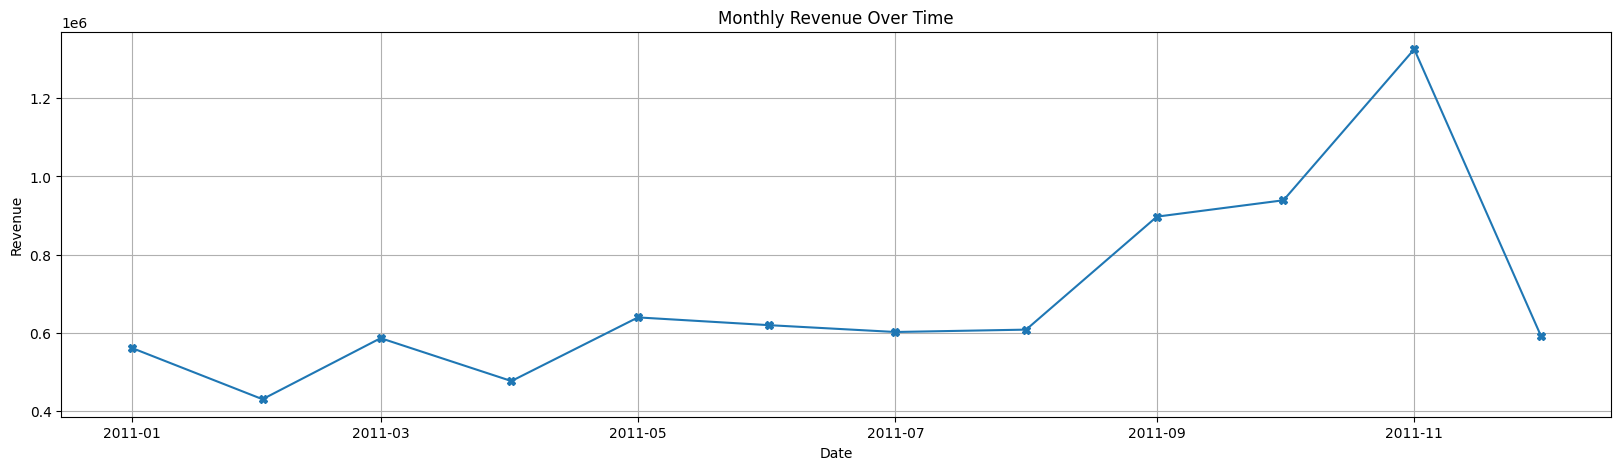

In [61]:
Revenue_Year = UK_df.groupby(['Year','Month'])['Revenue'].sum().reset_index()


Revenue_Year['YearMonth'] = pd.to_datetime(Revenue_Year['Year'].astype(str) + '-' + Revenue_Year['Month'].astype(str))


plt.figure(figsize=(20,5))
plt.plot(Revenue_Year['YearMonth'], Revenue_Year['Revenue'], marker='X')
plt.title("Monthly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()




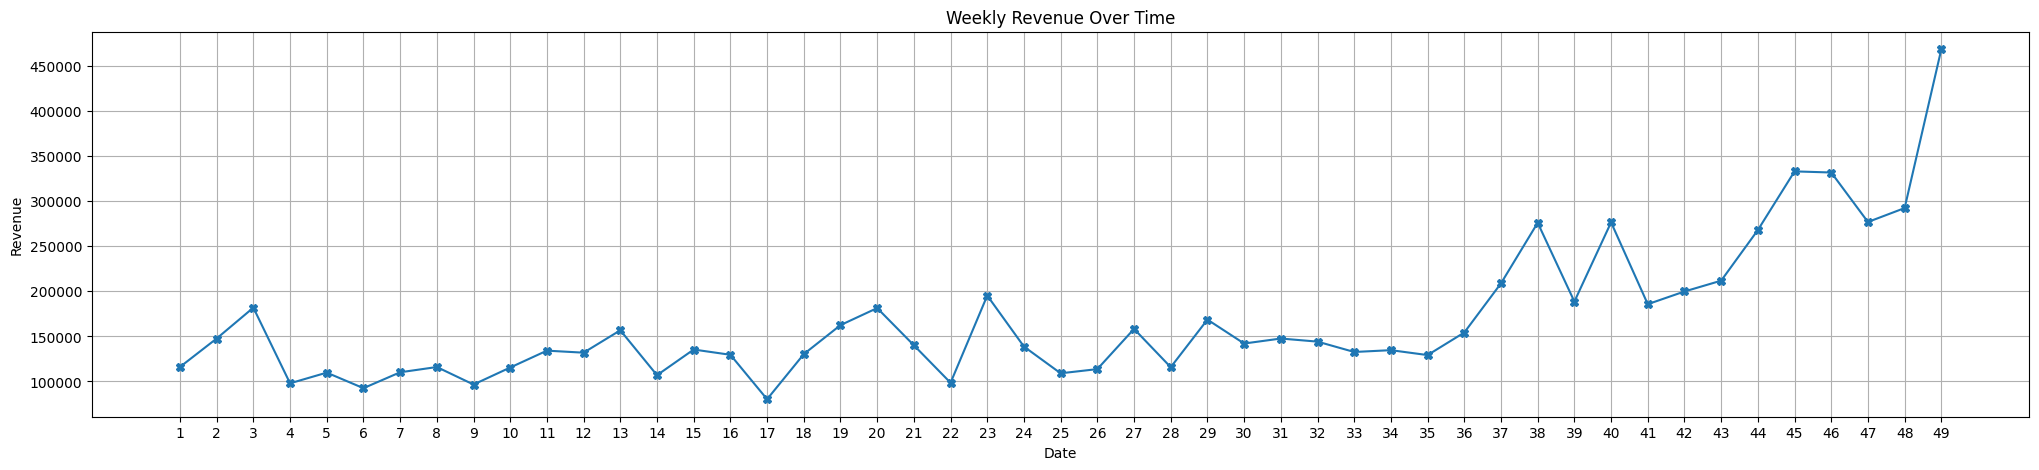

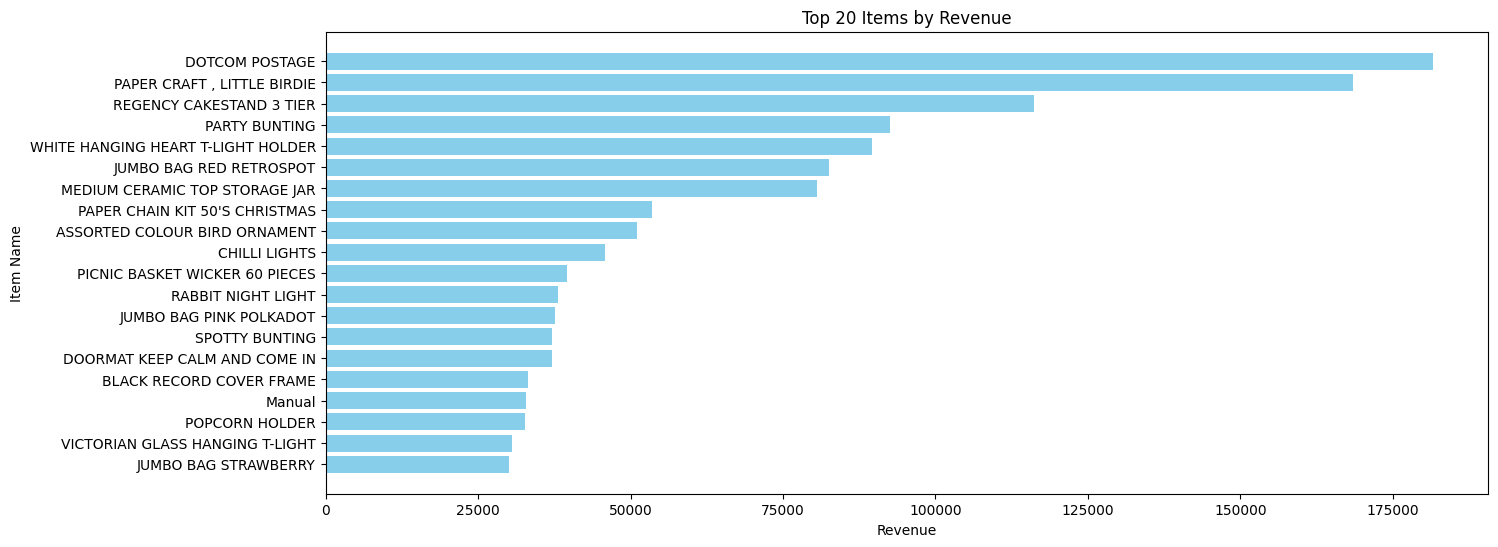

In [62]:
Revenue_Week = UK_df.groupby(['Week'])['Revenue'].sum().reset_index()
plt.figure(figsize=(25,5))
plt.plot(Revenue_Week['Week'], Revenue_Week['Revenue'], marker='X')
plt.title("Weekly Revenue Over Time")
plt.xticks(range(1, 50))
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()



Revenue_Item = UK_df.groupby('Itemname')['Revenue'].sum().reset_index().sort_values(by="Revenue", ascending=False)
top_items = Revenue_Item.head(20)
plt.figure(figsize=(15,6))
plt.barh(top_items['Itemname'], top_items['Revenue'], color='skyblue')
plt.title("Top 20 Items by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Item Name")
plt.gca().invert_yaxis()
plt.show()


In [63]:
basket= UK_df.groupby(['BillNo','Itemname'])['Quantity'].sum().unstack().reset_index().fillna(0).set_index('BillNo')
basket.describe()


Itemname,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,returned,taig adjust,test,to push order througha s stock was,website fixed,wrongly coded 20713,wrongly coded 23343,wrongly marked,wrongly marked 23343,wrongly sold (22719) barcode
count,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,...,16740.000000,16740.00000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000,16740.000000
mean,0.236858,0.105914,0.016965,0.006213,0.002509,0.054122,0.085006,0.165472,0.281422,0.355018,...,0.000239,0.00221,0.001374,0.000597,0.006571,0.047790,0.059737,0.002867,0.011947,0.010155
std,2.820261,1.618402,0.406881,0.095716,0.143750,0.861971,1.392675,2.196261,5.130714,6.994032,...,0.021860,0.27835,0.170213,0.077290,0.850188,6.183185,7.728982,0.370991,1.545796,1.313927
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,144.000000,100.000000,24.000000,2.000000,10.000000,36.000000,60.000000,121.000000,528.000000,480.000000,...,2.000000,36.00000,22.000000,10.000000,110.000000,800.000000,1000.000000,48.000000,200.000000,170.000000


In [64]:
basket = basket.clip(upper=1)
frequent_itemsets=apriori(basket,min_support=0.03,use_colnames=True)
frequent_itemsets


,support,itemsets
0,0.047013,(6 RIBBONS RUSTIC CHARM)
1,0.030227,(60 CAKE CASES VINTAGE CHRISTMAS)
2,0.041398,(60 TEATIME FAIRY CAKE CASES)
3,0.030585,(72 SWEETHEART FAIRY CAKE CASES)
4,0.046774,(ALARM CLOCK BAKELIKE GREEN)
...,...,...
137,0.039606,"(JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT)"
138,0.034409,"(LUNCH BAG BLACK SKULL., LUNCH BAG RED RETROS..."
139,0.031720,"(LUNCH BAG RED RETROSPOT, LUNCH BAG PINK POLKA..."
140,0.030824,"(LUNCH BAG RED RETROSPOT, LUNCH BAG SUKI DESIGN)"


In [65]:
Top_Basket=round(association_rules(frequent_itemsets,metric='lift',min_threshold=1),2)
Top_Basket_Sorted = Top_Basket.sort_values('support',ascending=False)
Top_Basket_Sorted.head(10)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.05,0.05,0.04,0.75,14.08,1.0,0.04,3.79,0.98,0.59,0.74,0.74
4,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.05,0.05,0.04,0.73,14.08,1.0,0.04,3.55,0.98,0.59,0.72,0.74
15,(JUMBO BAG RED RETROSPOT),(JUMBO STORAGE BAG SUKI),0.11,0.06,0.04,0.36,5.72,1.0,0.03,1.47,0.93,0.30,0.32,0.49
14,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.06,0.11,0.04,0.62,5.72,1.0,0.03,2.36,0.88,0.30,0.58,0.49
12,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.06,0.11,0.04,0.59,5.43,1.0,0.03,2.18,0.87,0.28,0.54,0.47
13,(JUMBO BAG RED RETROSPOT),(JUMBO SHOPPER VINTAGE RED PAISLEY),0.11,0.06,0.04,0.35,5.43,1.0,0.03,1.43,0.92,0.28,0.30,0.47
10,(JUMBO BAG RED RETROSPOT),(JUMBO BAG PINK POLKADOT),0.11,0.07,0.04,0.41,6.20,1.0,0.04,1.58,0.94,0.34,0.37,0.54
11,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.07,0.11,0.04,0.68,6.20,1.0,0.04,2.74,0.90,0.34,0.64,0.54
7,(JUMBO BAG RED RETROSPOT),(JUMBO BAG BAROQUE BLACK WHITE),0.11,0.05,0.03,0.30,5.81,1.0,0.03,1.35,0.93,0.25,0.26,0.47
6,(JUMBO BAG BAROQUE BLACK WHITE),(JUMBO BAG RED RETROSPOT),0.05,0.11,0.03,0.63,5.81,1.0,0.03,2.43,0.87,0.25,0.59,0.47


In [66]:
Top_Basket_Sorted[['antecedents','consequents','support','confidence','lift']].sort_values('confidence',ascending=False).head(5)


,antecedents,consequents,support,confidence,lift
3,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.03,0.82,15.74
23,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.03,0.78,14.58
5,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.04,0.75,14.08
4,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.04,0.73,14.08
1,(GARDENERS KNEELING PAD CUP OF TEA),(GARDENERS KNEELING PAD KEEP CALM),0.03,0.72,13.45


In [67]:
Top_Basket_Sorted[['antecedents','consequents','support','confidence','lift']].sort_values('lift',ascending=False).head(5)


,antecedents,consequents,support,confidence,lift
2,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.03,0.66,15.74
3,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.03,0.82,15.74
22,(ROSES REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.03,0.61,14.58
23,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.03,0.78,14.58
5,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.04,0.75,14.08


In [68]:
Top_Basket['score'] = Top_Basket['support'] * Top_Basket['confidence'] * Top_Basket['lift']


best_rules = Top_Basket.sort_values('score', ascending=False)


best_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'score']].head(5)


,antecedents,consequents,support,confidence,lift,score
5,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.04,0.75,14.08,0.422400
4,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.04,0.73,14.08,0.411136
3,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.03,0.82,15.74,0.387204
23,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.03,0.78,14.58,0.341172
2,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.03,0.66,15.74,0.311652


In [72]:
# Define seasons
def assign_season(month):
    if month in [11, 12]:
        return "Christmas"
    else:
        return "Normal"

UK_df['Season'] = UK_df['Month'].apply(assign_season)

season_revenue = UK_df.groupby('Season')['Revenue'].sum()
print(season_revenue)

def create_basket(data):
    basket = data.groupby(['BillNo','Itemname'])['Quantity']\
                 .sum().unstack().fillna(0)
    basket = basket.clip(upper=1)
    return basket

Season
Christmas    1917968.300
Normal       6358984.804
Name: Revenue, dtype: float64


In [73]:
christmas_df = UK_df[UK_df['Season'] == "Christmas"]
normal_df = UK_df[UK_df['Season'] == "Normal"]

basket_christmas = create_basket(christmas_df)
basket_normal = create_basket(normal_df)
# Christmas
freq_christmas = apriori(basket_christmas, min_support=0.03, use_colnames=True)
rules_christmas = association_rules(freq_christmas, metric='lift', min_threshold=1)

# Normal
freq_normal = apriori(basket_normal, min_support=0.03, use_colnames=True)
rules_normal = association_rules(freq_normal, metric='lift', min_threshold=1)

In [74]:
rules_christmas.sort_values('confidence', ascending=False).head(10)
rules_normal.sort_values('confidence', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
43,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.034616,0.056503,0.031564,0.911828,16.137793,1.0,0.029608,10.700641,0.971669,0.530000,0.906548,0.735229
44,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.036552,0.057917,0.031564,0.863544,14.910005,1.0,0.029447,6.903921,0.968325,0.501775,0.855155,0.704265
1,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.044368,0.056503,0.036552,0.823826,14.580300,1.0,0.034045,5.355471,0.974658,0.568287,0.813275,0.735365
41,(PINK REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.044368,0.057917,0.034616,0.780201,13.471009,1.0,0.032047,4.286118,0.968748,0.511551,0.766689,0.688944
3,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.056503,0.057917,0.042582,0.753623,13.012108,1.0,0.039309,3.823748,0.978433,0.592746,0.738477,0.744421
42,"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.042582,0.044368,0.031564,0.741259,16.706927,1.0,0.029675,3.693387,0.981958,0.569892,0.729246,0.726334
2,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.057917,0.056503,0.042582,0.735219,13.012108,1.0,0.039309,3.563306,0.979902,0.592746,0.719362,0.744421
47,(PINK REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, GREEN REGENC...",0.044368,0.042582,0.031564,0.711409,16.706927,1.0,0.029675,3.317566,0.983794,0.569892,0.698574,0.726334
9,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.072210,0.115015,0.048909,0.677320,5.888954,1.0,0.040604,2.742604,0.894805,0.353606,0.635383,0.551281
14,(JUMBO BAG STRAWBERRY),(JUMBO BAG RED RETROSPOT),0.048835,0.115015,0.031713,0.649390,5.646122,1.0,0.026096,2.524130,0.865136,0.240000,0.603824,0.462559
